# Notebook 2: Modeling

**FRE-GY 7773 — Group 2**: Zhang Xiaoyang, Zhao Zhiqi, Gupta Prachee

Models covered:
1. Baseline — Linear Regression
2. Logistic Regression + Ridge (L2)
3. Logistic Regression + Lasso (L1)
4. PCA + Logistic Regression
5. **Walk-Forward Validation** for robust evaluation

## 0. Imports & Load Data

In [52]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

train  = pd.read_csv('../data/train.csv', index_col=0, parse_dates=True)
test   = pd.read_csv('../data/test.csv',  index_col=0, parse_dates=True)
df_all = pd.concat([train, test]).sort_index()

with open('../data/config.json') as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
TARGET_COL   = config['target_col']

X_train = train[FEATURE_COLS].values
y_train = train[TARGET_COL].values
X_test  = test[FEATURE_COLS].values
y_test  = test[TARGET_COL].values

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1994, 10), Test: (500, 10)


## 1. Standard Scaling

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Done.')

Done.


## 2. Baseline — Linear Regression

In [54]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, train['next_return'].values)
y_pred_baseline = (linreg.predict(X_test_scaled) > 0).astype(int)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f'Baseline accuracy: {acc_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline, target_names=['Down','Up']))

Baseline accuracy: 0.4820
              precision    recall  f1-score   support

        Down       0.39      0.41      0.40       212
          Up       0.55      0.53      0.54       288

    accuracy                           0.48       500
   macro avg       0.47      0.47      0.47       500
weighted avg       0.48      0.48      0.48       500



## 3. Logistic + Ridge (L2)

In [55]:
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

ridge_lr = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000),
    param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
ridge_lr.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_lr.predict(X_test_scaled)
acc_ridge = accuracy_score(y_test, y_pred_ridge)
print(f'Best C: {ridge_lr.best_params_["C"]}  |  Test accuracy: {acc_ridge:.4f}')
print(classification_report(y_test, y_pred_ridge, target_names=['Down','Up']))

Best C: 0.001  |  Test accuracy: 0.5760
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       212
          Up       0.58      1.00      0.73       288

    accuracy                           0.58       500
   macro avg       0.29      0.50      0.37       500
weighted avg       0.33      0.58      0.42       500



## 4. Logistic + Lasso (L1)

In [56]:
lasso_lr = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
lasso_lr.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_lr.predict(X_test_scaled)
acc_lasso = accuracy_score(y_test, y_pred_lasso)
print(f'Best C: {lasso_lr.best_params_["C"]}  |  Test accuracy: {acc_lasso:.4f}')
print(classification_report(y_test, y_pred_lasso, target_names=['Down','Up']))

Best C: 0.1  |  Test accuracy: 0.5700
              precision    recall  f1-score   support

        Down       0.33      0.01      0.03       212
          Up       0.57      0.98      0.72       288

    accuracy                           0.57       500
   macro avg       0.45      0.50      0.38       500
weighted avg       0.47      0.57      0.43       500



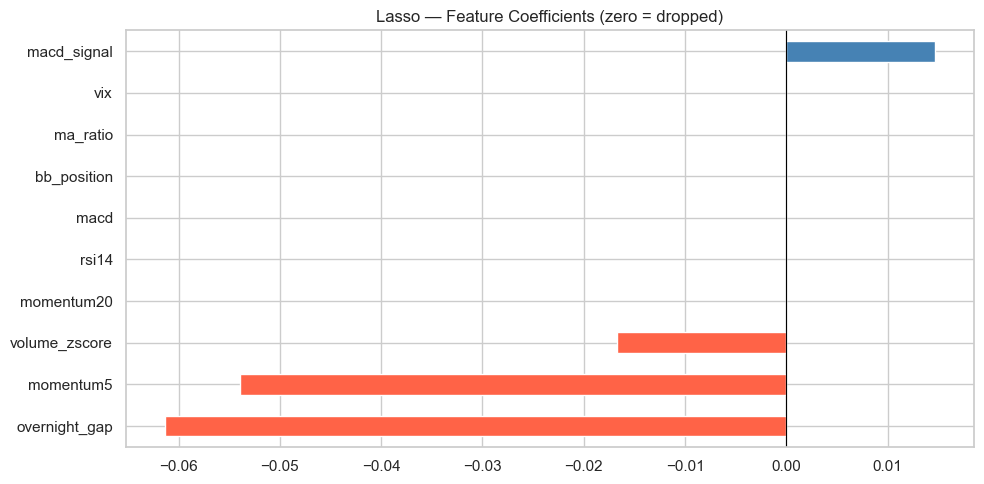

momentum5       -0.0539
macd_signal      0.0147
volume_zscore   -0.0167
overnight_gap   -0.0614


In [57]:
coefs = pd.Series(lasso_lr.best_estimator_.coef_[0], index=FEATURE_COLS)
fig, ax = plt.subplots()
coefs.sort_values().plot(kind='barh', ax=ax,
    color=['steelblue' if v >= 0 else 'tomato' for v in coefs.sort_values()])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso — Feature Coefficients (zero = dropped)')
plt.tight_layout()
plt.savefig('../results/02_lasso_coefficients.png', dpi=150)
plt.show()
print(coefs[coefs != 0].round(4).to_string())

## 5. PCA + Logistic Regression

In [58]:
pca_full = PCA().fit(X_train_scaled)
n_components = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
print(f'Components for 90% variance: {n_components}')

pca_pipe = Pipeline([
    ('pca', PCA(n_components=n_components)),
    ('clf', LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=1000))
])
pca_pipe.fit(X_train_scaled, y_train)
y_pred_pca = pca_pipe.predict(X_test_scaled)
acc_pca = accuracy_score(y_test, y_pred_pca)
print(f'PCA + Logistic accuracy: {acc_pca:.4f}')
print(classification_report(y_test, y_pred_pca, target_names=['Down','Up']))

Components for 90% variance: 5
PCA + Logistic accuracy: 0.5640
              precision    recall  f1-score   support

        Down       0.38      0.04      0.08       212
          Up       0.57      0.95      0.71       288

    accuracy                           0.56       500
   macro avg       0.47      0.50      0.40       500
weighted avg       0.49      0.56      0.44       500



## 5.5 XGBoost

Tree-based model that captures non-linear feature interactions.
Does not require scaling. Tuned via GridSearchCV + TimeSeriesSplit.

In [59]:
xgb_param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_param_grid, cv=tscv, scoring='accuracy', n_jobs=1)
xgb_gs.fit(X_train, y_train)

y_pred_xgb = xgb_gs.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'Best params: {xgb_gs.best_params_}')
print(f'Test accuracy: {acc_xgb:.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['Down', 'Up']))

Best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
Test accuracy: 0.5720
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       212
          Up       0.57      0.99      0.73       288

    accuracy                           0.57       500
   macro avg       0.29      0.50      0.36       500
weighted avg       0.33      0.57      0.42       500



## 6. Single-Split Comparison

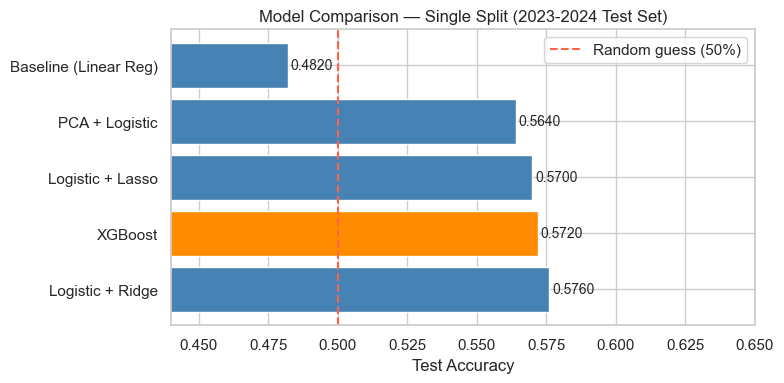

                Model  Test Accuracy
     Logistic + Ridge          0.576
              XGBoost          0.572
     Logistic + Lasso          0.570
       PCA + Logistic          0.564
Baseline (Linear Reg)          0.482


In [60]:
results = pd.DataFrame({
    'Model': ['Baseline (Linear Reg)', 'Logistic + Ridge', 'Logistic + Lasso', 'PCA + Logistic', 'XGBoost'],
    'Test Accuracy': [acc_baseline, acc_ridge, acc_lasso, acc_pca, acc_xgb]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['darkorange' if m == 'XGBoost' else 'steelblue' for m in results['Model']]
bars = ax.barh(results['Model'], results['Test Accuracy'], color=colors_bar)
ax.axvline(0.5, color='tomato', linestyle='--', label='Random guess (50%)')
for bar, val in zip(bars, results['Test Accuracy']):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0.44, 0.65)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison — Single Split (2023-2024 Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/02_model_comparison.png', dpi=150)
plt.show()
print(results.to_string(index=False))

## 7. Walk-Forward Validation

A single train/test split depends heavily on the chosen test period. Walk-Forward Validation tests across **multiple non-overlapping yearly windows**, giving a more robust estimate of true out-of-sample performance.

The training window always expands — the test window is always unseen future data.

In [61]:
FOLDS = [
    ('2015-01-01', '2018-12-31', '2019-01-01', '2019-12-31'),
    ('2015-01-01', '2019-12-31', '2020-01-01', '2020-12-31'),
    ('2015-01-01', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2015-01-01', '2021-12-31', '2022-01-01', '2022-12-31'),
    ('2015-01-01', '2022-12-31', '2023-01-01', '2023-12-31'),
]

wf_records = []

for train_start, train_end, test_start, test_end in FOLDS:
    fold_train = df_all.loc[train_start:train_end]
    fold_test  = df_all.loc[test_start:test_end]

    Xtr = fold_train[FEATURE_COLS].values
    ytr = fold_train[TARGET_COL].values
    Xte = fold_test[FEATURE_COLS].values
    yte = fold_test[TARGET_COL].values

    sc    = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    row = {'test_year': test_start[:4]}

    # Ridge
    m_ridge = LogisticRegression(penalty='l2', solver='lbfgs',
                                  C=ridge_lr.best_params_['C'], max_iter=1000)
    m_ridge.fit(Xtr_s, ytr)
    row['Logistic + Ridge'] = accuracy_score(yte, m_ridge.predict(Xte_s))

    # Lasso
    m_lasso = LogisticRegression(penalty='l1', solver='liblinear',
                                  C=lasso_lr.best_params_['C'], max_iter=1000)
    m_lasso.fit(Xtr_s, ytr)
    row['Logistic + Lasso'] = accuracy_score(yte, m_lasso.predict(Xte_s))

    # XGBoost (no scaling needed)
    m_xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1,
                           **xgb_gs.best_params_)
    m_xgb.fit(Xtr, ytr)
    row['XGBoost'] = accuracy_score(yte, m_xgb.predict(Xte))

    wf_records.append(row)

wf_df = pd.DataFrame(wf_records).set_index('test_year')
print('Walk-Forward Accuracy by Year:')
print(wf_df.round(4).to_string())
print()
print('Mean / Std across folds:')
print(wf_df.agg(['mean','std']).round(4).to_string())

Walk-Forward Accuracy by Year:
           Logistic + Ridge  Logistic + Lasso  XGBoost
test_year                                             
2019                 0.5952            0.5595   0.5913
2020                 0.5731            0.5731   0.5731
2021                 0.5833            0.5833   0.5833
2022                 0.4263            0.4422   0.4303
2023                 0.5600            0.5520   0.5560

Mean / Std across folds:
      Logistic + Ridge  Logistic + Lasso  XGBoost
mean            0.5476            0.5420   0.5468
std             0.0690            0.0571   0.0665


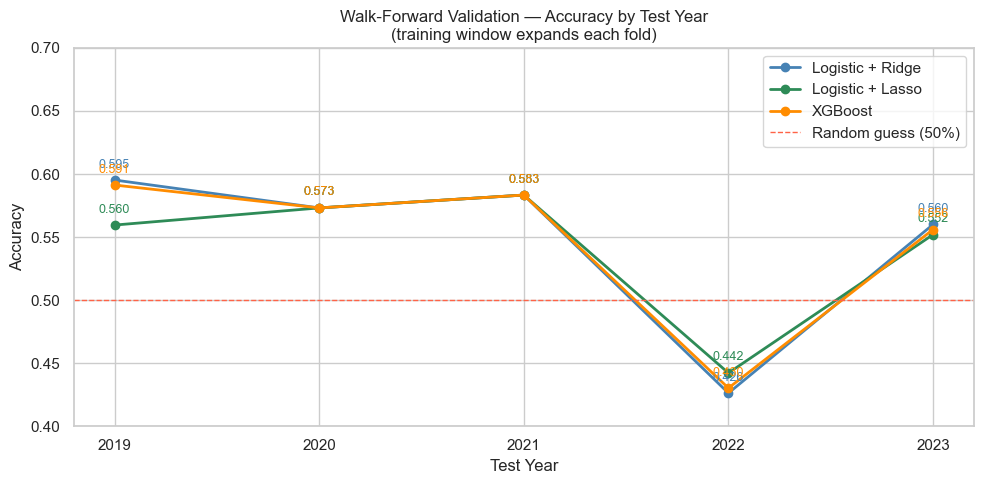

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Logistic + Ridge': 'steelblue', 'Logistic + Lasso': 'seagreen', 'XGBoost': 'darkorange'}

for col in wf_df.columns:
    ax.plot(wf_df.index, wf_df[col], marker='o', label=col,
            color=colors[col], linewidth=2)
    for x, y in zip(wf_df.index, wf_df[col]):
        ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=9, color=colors[col])

ax.axhline(0.5, color='tomato', linestyle='--', linewidth=1, label='Random guess (50%)')
ax.set_ylim(0.40, 0.70)
ax.set_xlabel('Test Year')
ax.set_ylabel('Accuracy')
ax.set_title('Walk-Forward Validation — Accuracy by Test Year\n(training window expands each fold)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/02_walk_forward_accuracy.png', dpi=150)
plt.show()

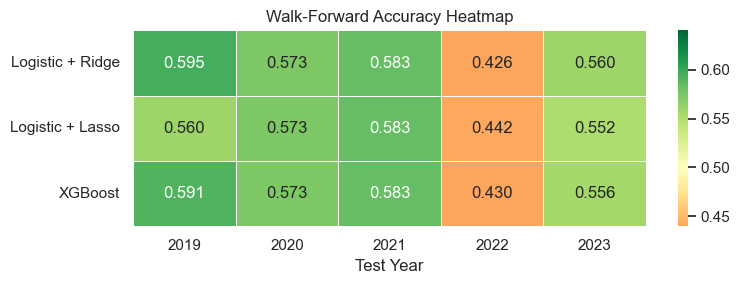

In [63]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(wf_df.T, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0.5, vmin=0.44, vmax=0.64, linewidths=0.5, ax=ax)
ax.set_title('Walk-Forward Accuracy Heatmap')
ax.set_xlabel('Test Year')
plt.tight_layout()
plt.savefig('../results/02_walk_forward_heatmap.png', dpi=150)
plt.show()

## 8. Save Predictions

In [ ]:
test_out = test[['Close', 'next_return', 'target']].copy()

# Hard predictions
test_out['pred_baseline'] = y_pred_baseline
test_out['pred_ridge']    = y_pred_ridge
test_out['pred_lasso']    = y_pred_lasso
test_out['pred_pca']      = y_pred_pca
test_out['pred_xgb']      = y_pred_xgb

# Predicted probabilities of Up (class=1) — used for probability filtering
test_out['proba_ridge'] = ridge_lr.predict_proba(X_test_scaled)[:, 1]
test_out['proba_lasso'] = lasso_lr.predict_proba(X_test_scaled)[:, 1]
test_out['proba_pca']   = pca_pipe.predict_proba(X_test_scaled)[:, 1]
test_out['proba_xgb']   = xgb_gs.predict_proba(X_test)[:, 1]

test_out.to_csv('../data/test_predictions.csv')
wf_df.to_csv('../results/02_walk_forward_results.csv')
print('Saved: data/test_predictions.csv')
print('Saved: results/02_walk_forward_results.csv')
print(f'\nProba columns summary:')
for col in ['proba_ridge','proba_lasso','proba_xgb']:
    print(f'  {col}: min={test_out[col].min():.3f}  mean={test_out[col].mean():.3f}  max={test_out[col].max():.3f}')

## 9. Test Set Accuracy — Visual Comparison

Three views of model performance on the 2023-2024 test set:
1. **Bar chart** — overall accuracy per model vs random baseline
2. **Rolling accuracy** — 30-day rolling window accuracy over time
3. **Cumulative correct predictions** — how accuracy accumulates day by day

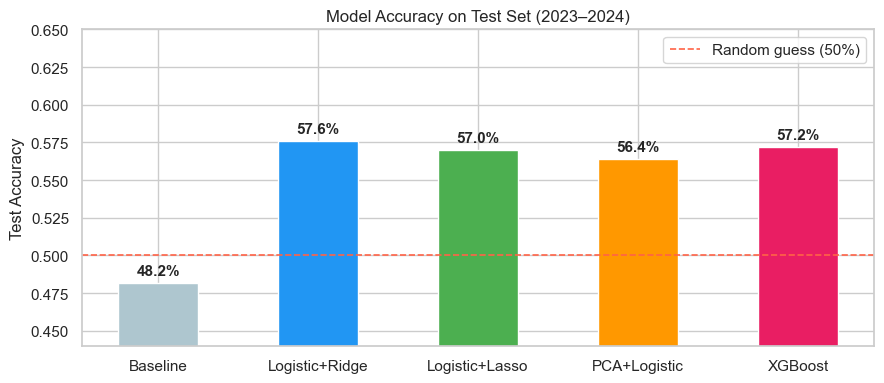

In [68]:
preds = pd.read_csv('../data/test_predictions.csv', index_col=0, parse_dates=True)

all_models = {
    'Baseline':        'pred_baseline',
    'Logistic+Ridge':  'pred_ridge',
    'Logistic+Lasso':  'pred_lasso',
    'PCA+Logistic':    'pred_pca',
    'XGBoost':         'pred_xgb',
}
# only include models whose predictions are saved
models  = {k: v for k, v in all_models.items() if v in preds.columns}
palette = ['#aec6cf', '#2196F3', '#4CAF50', '#FF9800', '#E91E63'][:len(models)]

accuracies = {name: (preds[col] == preds['target']).mean() for name, col in models.items()}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(accuracies.keys()), list(accuracies.values()), color=palette, width=0.5)
ax.axhline(0.5, color='tomato', linestyle='--', linewidth=1.2, label='Random guess (50%)')
for bar, val in zip(bars, accuracies.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0.44, 0.65)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Accuracy on Test Set (2023–2024)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/02_test_accuracy_bar.png', dpi=150)
plt.show()

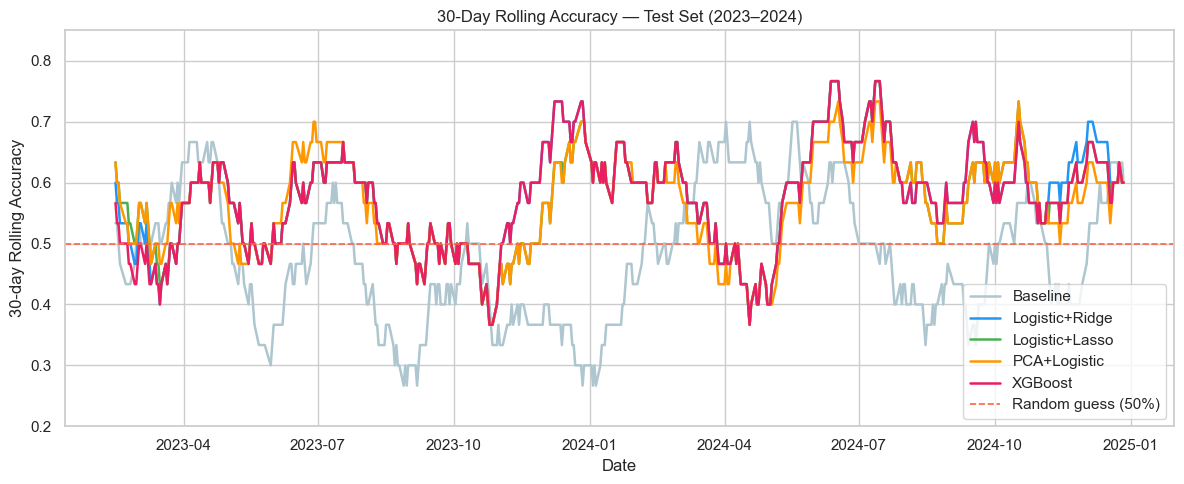

In [69]:
WINDOW = 30
fig, ax = plt.subplots(figsize=(12, 5))

for (name, col), color in zip(models.items(), palette):
    correct = (preds[col] == preds['target']).astype(float)
    rolling = correct.rolling(WINDOW).mean()
    ax.plot(preds.index, rolling, label=name, color=color, linewidth=1.8)

ax.axhline(0.5, color='tomato', linestyle='--', linewidth=1.2, label='Random guess (50%)')
ax.set_ylabel(f'{WINDOW}-day Rolling Accuracy')
ax.set_xlabel('Date')
ax.set_title(f'{WINDOW}-Day Rolling Accuracy — Test Set (2023–2024)')
ax.legend(loc='lower right')
ax.set_ylim(0.2, 0.85)
plt.tight_layout()
plt.savefig('../results/02_test_rolling_accuracy.png', dpi=150)
plt.show()

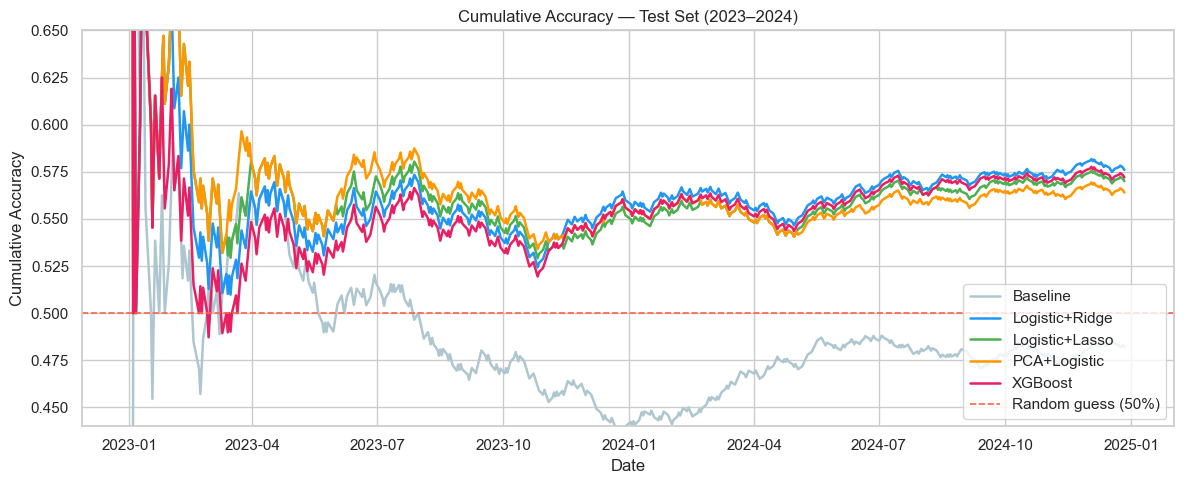

In [70]:
fig, ax = plt.subplots(figsize=(12, 5))

n = len(preds)
days = range(1, n + 1)

for (name, col), color in zip(models.items(), palette):
    correct = (preds[col] == preds['target']).astype(float)
    cumulative_acc = correct.cumsum() / days
    ax.plot(preds.index, cumulative_acc, label=name, color=color, linewidth=1.8)

ax.axhline(0.5, color='tomato', linestyle='--', linewidth=1.2, label='Random guess (50%)')
ax.set_ylabel('Cumulative Accuracy')
ax.set_xlabel('Date')
ax.set_title('Cumulative Accuracy — Test Set (2023–2024)')
ax.legend(loc='lower right')
ax.set_ylim(0.44, 0.65)
plt.tight_layout()
plt.savefig('../results/02_test_cumulative_accuracy.png', dpi=150)
plt.show()